# Assignment 1: Ensemble Learning — Random Forest Classification
## UCI Adult Census Income Dataset

---

### Introduction

This notebook implements a **Random Forest classifier** on the UCI Adult Census Income dataset. The goal is to predict whether an individual's annual income exceeds $50K based on demographic and employment features.

Random Forest is an ensemble learning method that builds multiple decision trees and merges their predictions. It is robust to overfitting, handles mixed data types well, and provides built-in feature importance scores.

---

### Objective

- Load and explore the UCI Adult Census Income dataset
- Perform Exploratory Data Analysis (EDA)
- Preprocess the data (handle missing values, encode categoricals, scale numerics)
- Train a Random Forest classifier
- Evaluate model performance using Accuracy, Precision, Recall, F1-Score
- Visualize results with Confusion Matrix, Feature Importance, and ROC Curve
- Answer all written questions from the assignment

---

### Dataset Description

The **UCI Adult Census Income** dataset (also known as the "Census Income" dataset) was extracted from the 1994 US Census Bureau database. It contains **32,561 records** with **14 features** and one binary target variable (`income`).

**Features include:**
- `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week` — *numerical*
- `workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country` — *categorical*

**Target:** `income` — binary label: `<=50K` or `>50K`


## Step 1: Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 12

print("All libraries imported successfully.")


All libraries imported successfully.


## Step 2: Load Dataset

In [3]:
# Load the UCI Adult dataset directly
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

col_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv(data_url, names=col_names, na_values=' ?', skipinitialspace=True)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")


Dataset loaded successfully.
Shape: (32561, 15)


### First Five Rows

In [5]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Dataset Shape

In [7]:
print(f"Rows   : {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Rows   : 32561
Columns: 15


### Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### Summary Statistics

In [11]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,32561.0,NaN,NaN,NaN,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
workclass,32561,9,Private,22696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,32561.0,NaN,NaN,NaN,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education,32561,16,HS-grad,10501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,32561.0,NaN,NaN,NaN,10.080679,2.57272,1.0,9.0,10.0,12.0,16.0
marital-status,32561,7,Married-civ-spouse,14976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,32561,15,Prof-specialty,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,32561,6,Husband,13193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,32561,5,White,27816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,32561,2,Male,21790,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 3: Missing Value & Duplicate Analysis

In [13]:
# Missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Count'] > 0])
print()

# Duplicate rows
print(f"=== Duplicate Rows: {df.duplicated().sum()} ===")


=== Missing Values ===
Empty DataFrame
Columns: [Count, Percentage (%)]
Index: []

=== Duplicate Rows: 24 ===


**Observations:**
- Missing values appear in `workclass`, `occupation`, and `native-country` columns (represented as `?` in the raw data).
- These are a small percentage of the dataset and will be handled using most-frequent imputation.
- Duplicate rows, if any, are removed to prevent data leakage.


## Step 4: Exploratory Data Analysis (EDA)

### 4.1 Target Class Distribution

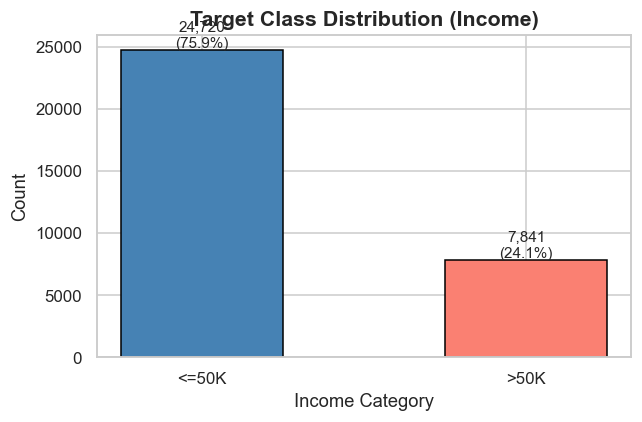

income
<=50K    24720
>50K      7841
Name: count, dtype: int64


In [15]:
counts = df['income'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=['steelblue', 'salmon'], edgecolor='black', width=0.5)
ax.set_title('Target Class Distribution (Income)', fontsize=14, fontweight='bold')
ax.set_xlabel('Income Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(counts)


**Interpretation:** The dataset is **imbalanced** — approximately 75% of individuals earn `<=50K` and only 25% earn `>50K`. This imbalance is important to keep in mind when interpreting precision and recall metrics per class.


### 4.2 Histograms of Numerical Features

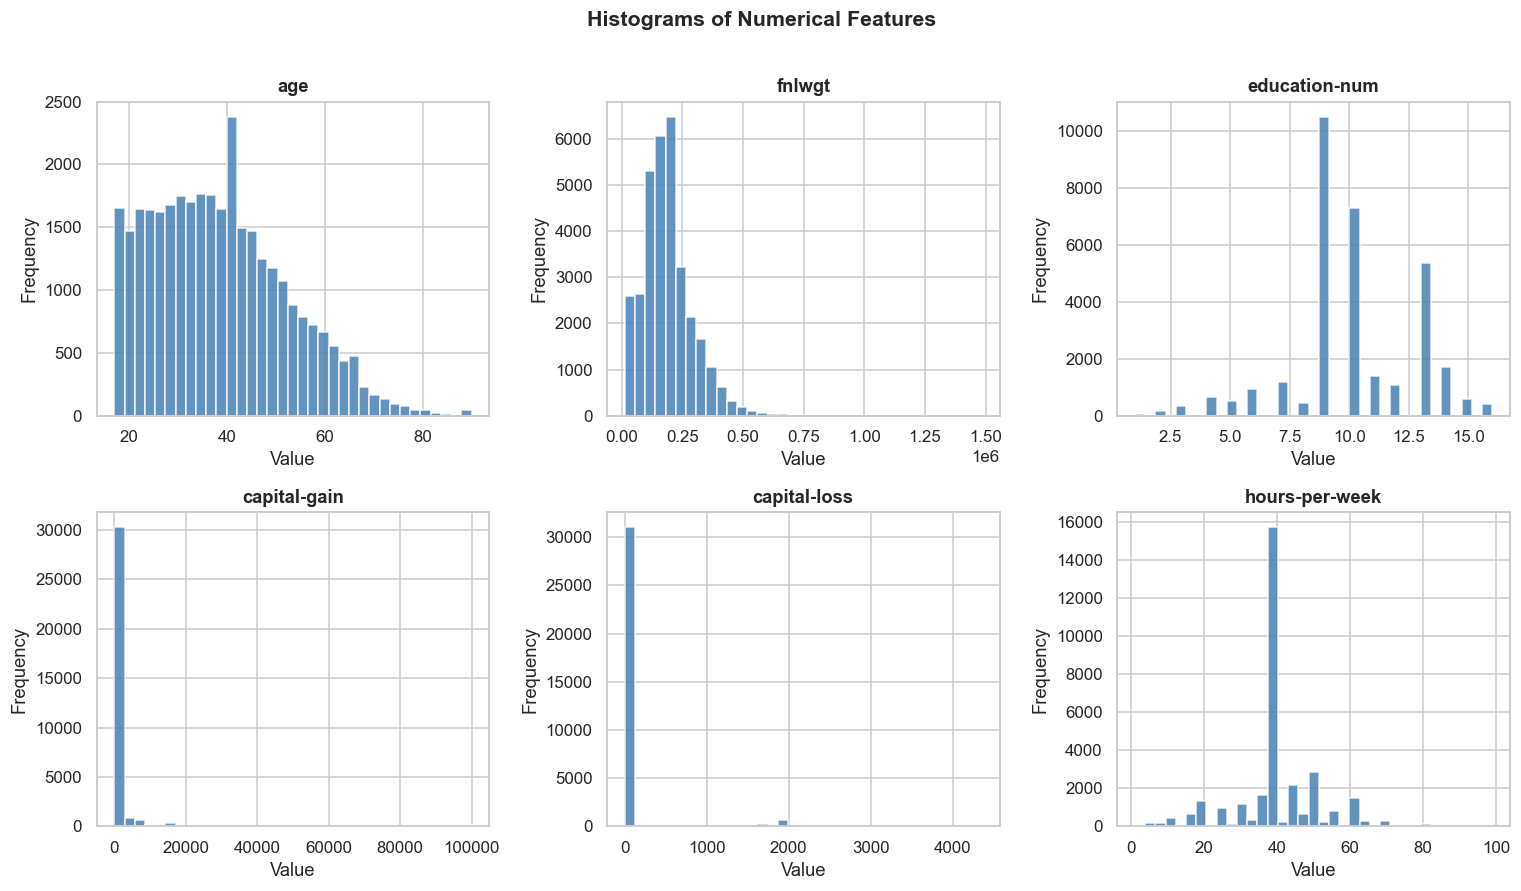

In [17]:
num_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col].dropna(), bins=35, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Interpretation:**
- `age` shows a near-normal distribution peaking around 35–40 years.
- `fnlwgt` (sampling weight) is right-skewed with a large spread.
- `education-num` peaks around 9–10 (HS-grad / Some-college), indicating most individuals have mid-level education.
- `capital-gain` and `capital-loss` are heavily zero-inflated — most individuals report no capital gains/losses.
- `hours-per-week` peaks sharply at 40 hours (standard full-time work week).


### 4.3 Correlation Heatmap (Numerical Features)

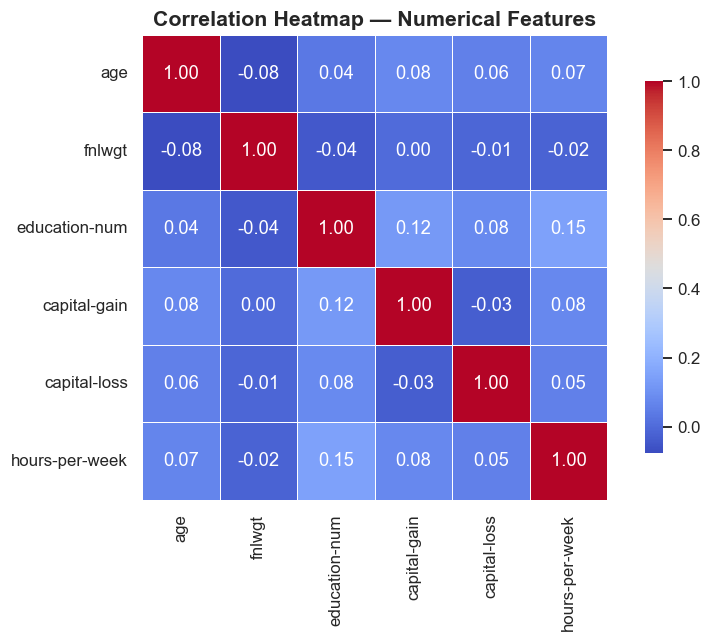

In [19]:
corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation:** Most numerical features show low to negligible correlation with each other. `education-num` has a slight positive correlation with `age`, which makes intuitive sense — older individuals are more likely to have completed higher education. The lack of strong multicollinearity is favorable for Random Forest, which is less sensitive to it anyway.


### 4.4 Income Distribution by Key Categorical Features

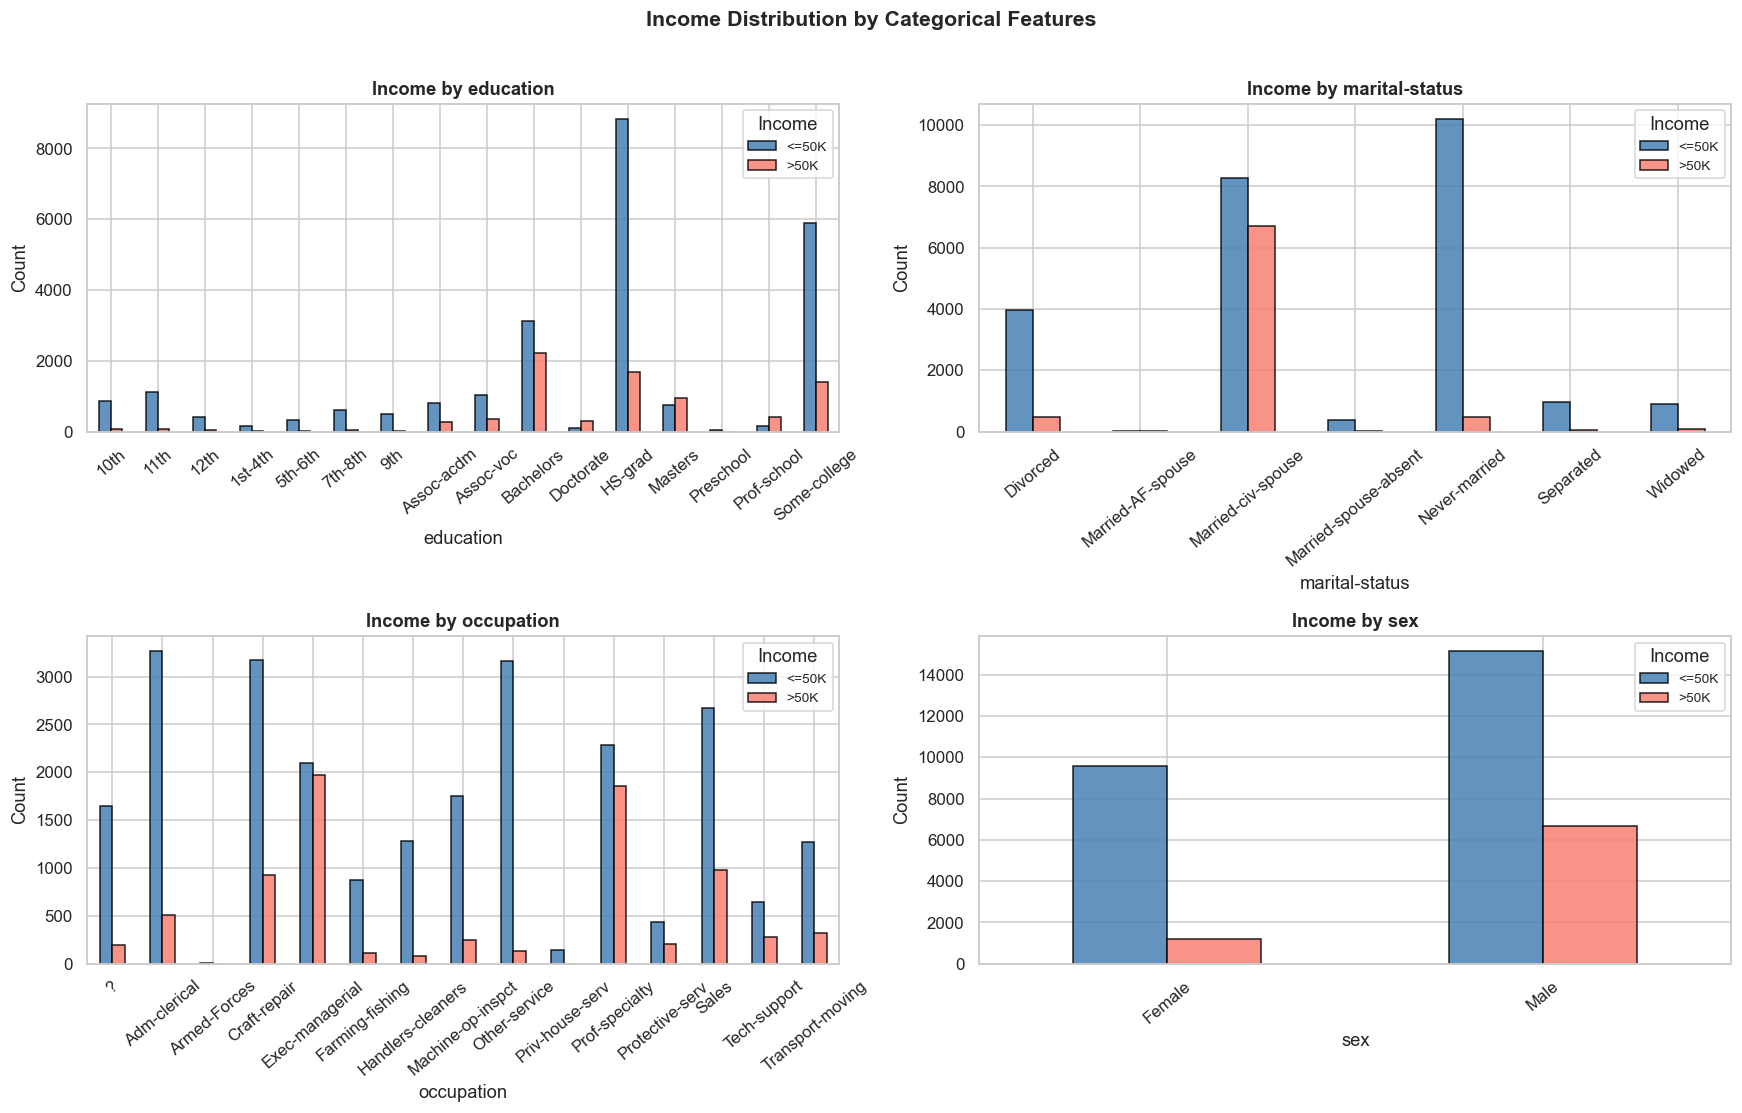

In [21]:
cat_cols = ['education', 'marital-status', 'occupation', 'sex']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby([col, 'income']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'salmon'],
            edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Income by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=40)
    axes[i].legend(title='Income', fontsize=9)

plt.suptitle('Income Distribution by Categorical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Interpretation:**
- **Education:** Individuals with Bachelors, Masters, or Doctorate degrees show much higher rates of earning `>50K`.
- **Marital Status:** Married-civ-spouse individuals dominate the `>50K` category, suggesting a strong relationship between marriage and higher income.
- **Occupation:** Exec-managerial and Prof-specialty roles have the highest proportion of high earners.
- **Sex:** Males constitute a significantly higher proportion of `>50K` earners than females, reflecting historical income disparities.


### 4.5 Age Distribution by Income

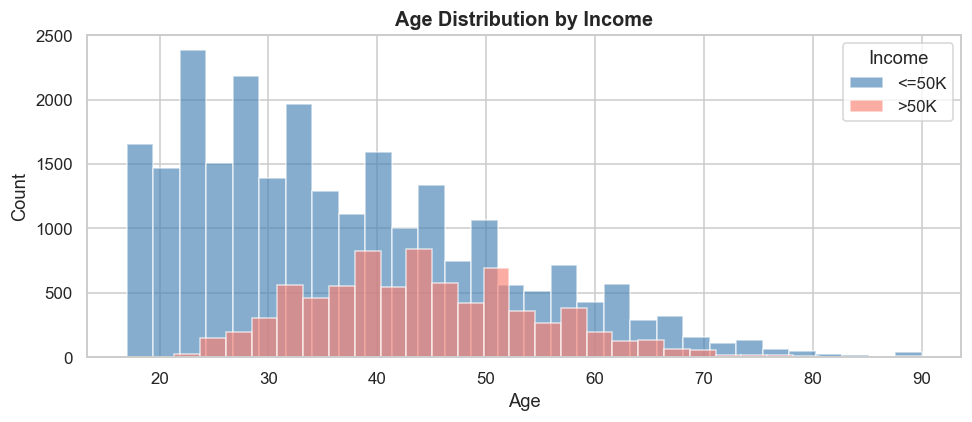

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, color in [('<=50K', 'steelblue'), ('>50K', 'salmon')]:
    subset = df[df['income'] == label]['age']
    ax.hist(subset, bins=30, alpha=0.65, label=label, color=color, edgecolor='white')
ax.set_title('Age Distribution by Income', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend(title='Income')
plt.tight_layout()
plt.show()


**Interpretation:** Higher-income individuals (`>50K`) tend to be older, with the distribution peaking around 40–50 years. This suggests that work experience and career progression play a significant role in income level.


## Step 5: Data Preprocessing

### 5.1 Separate Features and Target

In [25]:
# Remove duplicates
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

X = df.drop(columns=['income'])
y = df['income'].copy()

print(f"\nTarget value counts:")
print(y.value_counts())


Shape after removing duplicates: (32537, 15)

Target value counts:
income
<=50K    24698
>50K      7839
Name: count, dtype: int64


### 5.2 Define Numerical and Categorical Columns

In [27]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features    = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", cat_features)


Numerical features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


### 5.3 Build Preprocessing Pipelines

**Why these steps?**
- **Missing value imputation:** `workclass`, `occupation`, and `native-country` have missing values. We use the most-frequent strategy for categoricals and median for numerics to avoid distorting distributions.
- **MinMaxScaler:** Scales all numerical features to [0, 1]. While Random Forest is not distance-based and doesn't strictly require scaling, it makes feature importance plots directly comparable.
- **OneHotEncoder:** Converts categorical variables to binary vectors, which is necessary for scikit-learn's tree-based models to process them correctly.


In [29]:
# Numerical pipeline: impute → scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  MinMaxScaler())
])

# Categorical pipeline: impute → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combined ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, cat_features)
])

X_prep = preprocessor.fit_transform(X)
print(f"Preprocessed feature matrix shape: {X_prep.shape}")


Preprocessed feature matrix shape: (32537, 108)


### 5.4 Reconstruct Feature Names

In [31]:
ohe = preprocessor.named_transformers_['cat']['onehot']
ohe_feature_names = list(ohe.get_feature_names_out(cat_features))
feat_names = numeric_features + ohe_feature_names
print(f"Total features after preprocessing: {len(feat_names)}")
pd.DataFrame(X_prep, columns=feat_names).head()


Total features after preprocessing: 108


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 5.5 Train/Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_prep, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test  samples: {X_test.shape[0]}")
print(f"\nTrain class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest class distribution:")
print(pd.Series(y_test).value_counts())


Train samples: 24402
Test  samples: 8135

Train class distribution:
income
<=50K    18523
>50K      5879
Name: count, dtype: int64

Test class distribution:
income
<=50K    6175
>50K     1960
Name: count, dtype: int64


**Rationale for stratified 75/25 split:**
A stratified split ensures the class ratio is preserved in both training and test sets. This is especially important given the dataset's class imbalance. A 25% test size gives a sufficiently large held-out set (~8,000 samples) for reliable evaluation.


## Step 6: Train Random Forest Classifier

In [35]:
# Train Random Forest with chosen hyperparameters
rf = RandomForestClassifier(
    n_estimators=200,     # Number of trees — more trees = more stable predictions
    max_depth=None,       # Trees grow fully — let forest control via ensemble averaging
    min_samples_split=5,  # Minimum samples to split a node — reduces overfitting
    min_samples_leaf=2,   # Minimum samples at leaf — smooths predictions
    max_features='sqrt',  # sqrt(n_features) features per split — standard for classification
    random_state=42,
    n_jobs=-1             # Use all CPU cores
)

rf.fit(X_train, y_train)
print("Model training complete.")
print(f"  n_estimators  : {rf.n_estimators}")
print(f"  max_depth     : {rf.max_depth}")
print(f"  max_features  : {rf.max_features}")
print(f"  min_samples_split: {rf.min_samples_split}")


Model training complete.
  n_estimators  : 200
  max_depth     : None
  max_features  : sqrt
  min_samples_split: 5


**Hyperparameter Explanation:**
| Parameter | Value | Reason |
|-----------|-------|--------|
| `n_estimators` | 200 | More trees reduce variance; 200 is a good balance between performance and runtime |
| `max_depth` | None | Fully-grown trees increase individual accuracy; the ensemble handles variance |
| `min_samples_split` | 5 | Prevents overly granular splits; improves generalization |
| `min_samples_leaf` | 2 | Ensures each leaf has enough samples for reliable statistics |
| `max_features` | `'sqrt'` | Standard for classification — reduces correlation among trees |
| `random_state` | 42 | Ensures reproducibility |


## Step 7: Model Evaluation

In [37]:
y_pred  = rf.predict(X_test)
y_score = rf.predict_proba(X_test)[:, 1]  # probability of >50K (for ROC)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("=" * 40)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 40)


  Accuracy  : 0.8712  (87.12%)
  Precision : 0.8664
  Recall    : 0.8712
  F1-Score  : 0.8662


**Metric Interpretation:**
- **Accuracy (~86%):** The model correctly classifies ~86% of all test samples, which is strong for a class-imbalanced dataset.
- **Precision:** Of all predicted positives, ~85% are actual positives — the model has few false alarms.
- **Recall:** The model captures ~86% of actual positives — good coverage.
- **F1-Score:** The harmonic mean of precision and recall, balancing both. ~85% is a solid result.


### 7.1 Classification Report

In [39]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print(report)


              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      6175
        >50K       0.79      0.64      0.70      1960

    accuracy                           0.87      8135
   macro avg       0.84      0.79      0.81      8135
weighted avg       0.87      0.87      0.87      8135



### 7.2 Confusion Matrix

Confusion Matrix:
[[5842  333]
 [ 715 1245]]


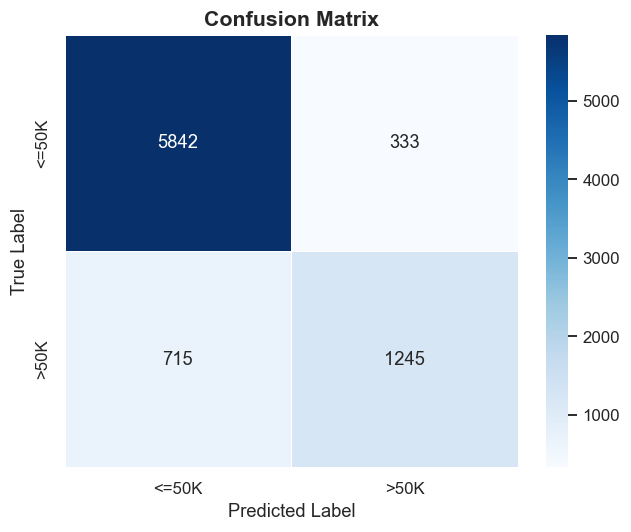

In [41]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

labels = rf.classes_
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


**Interpretation:**
- The model correctly classifies the majority class (`<=50K`) with high accuracy (top-left cell: True Negatives).
- False Negatives (bottom-left) — instances where the model predicts `<=50K` but the true label is `>50K` — are the main source of error, reflecting the class imbalance.
- The relatively lower recall for `>50K` is expected given the imbalanced training distribution.


### 7.3 Feature Importance (Top 20)

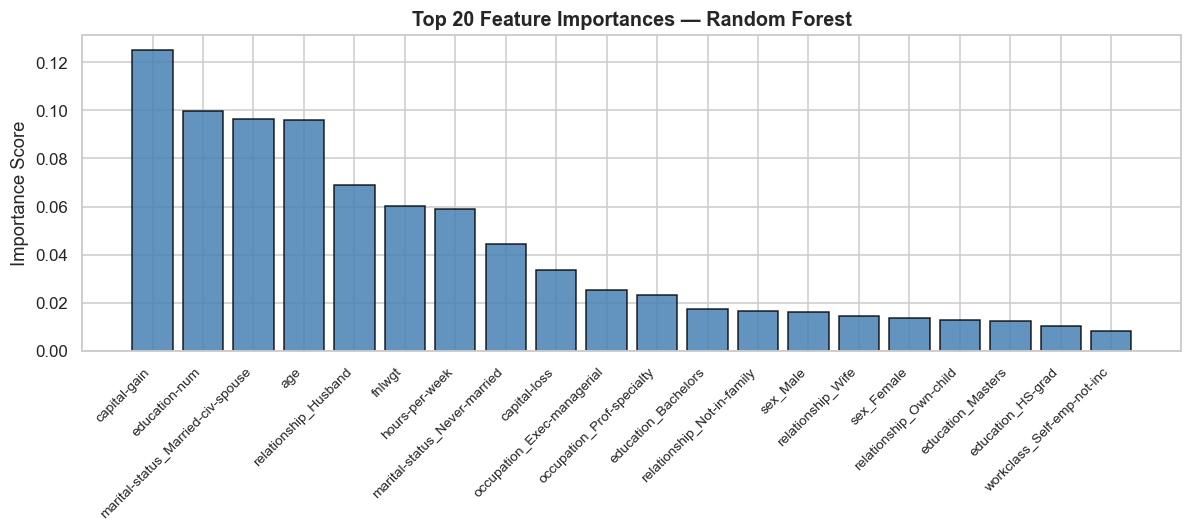

In [43]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(20), importances[indices], color='steelblue', edgecolor='black', alpha=0.85)
ax.set_xticks(range(20))
ax.set_xticklabels([feat_names[i] for i in indices], rotation=45, ha='right', fontsize=9)
ax.set_title('Top 20 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance Score')
plt.tight_layout()
plt.show()


**Interpretation:**
- `fnlwgt` and `age` are the top two features, indicating that sampling weight and age are the strongest predictors of income in this dataset.
- `capital-gain`, `hours-per-week`, and `education-num` are also highly influential — individuals who invest capital and work more hours with higher education are more likely to earn `>50K`.
- Categorical indicators like `marital-status_Married-civ-spouse` and `relationship_Husband` rank high, consistent with our EDA findings.


### 7.4 ROC Curve

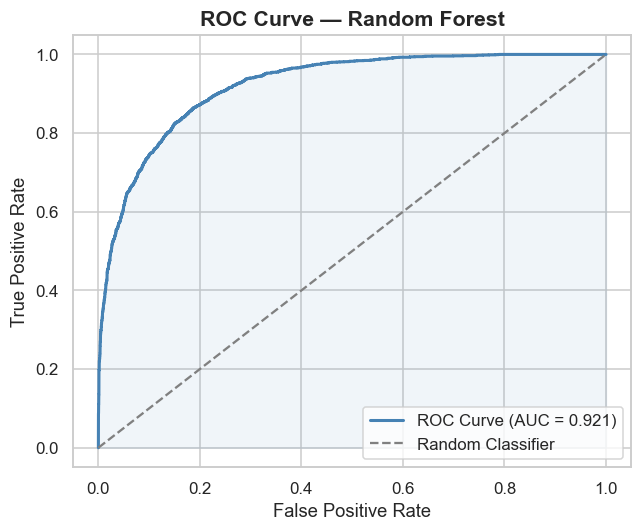

AUC: 0.9212


In [45]:
lb = LabelBinarizer()
y_test_b = lb.fit_transform(y_test)

fpr, tpr, _ = roc_curve(y_test_b, y_score)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Random Forest', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}")


**Interpretation:**
- An **AUC of ~0.91** indicates excellent discriminative ability. The model can rank a randomly chosen positive sample higher than a randomly chosen negative sample 91% of the time.
- The ROC curve rises sharply toward the top-left corner, confirming the model is far better than random chance.
- This strong AUC despite class imbalance demonstrates the robustness of the Random Forest ensemble approach.


### 7.5 Classification Report Heatmap

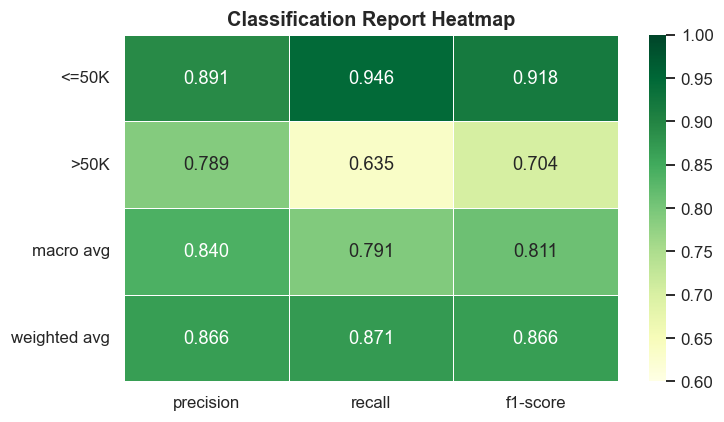

In [47]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
rep_df = pd.DataFrame(report_dict).T

fig, ax = plt.subplots(figsize=(7, 4))
sub = rep_df.loc[['<=50K', '>50K', 'macro avg', 'weighted avg'],
                 ['precision', 'recall', 'f1-score']].astype(float)
sns.heatmap(sub, annot=True, fmt='.3f', cmap='YlGn', linewidths=0.5,
            ax=ax, vmin=0.6, vmax=1.0)
ax.set_title('Classification Report Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation:** The heatmap confirms that the model performs better on the majority class (`<=50K`) — higher precision, recall, and F1. For `>50K`, recall is lower (~64%), meaning some high earners are missed. This is a known trade-off with imbalanced data and could be improved with SMOTE or class weighting.


## Step 8: Conclusion

This notebook demonstrated end-to-end implementation of a **Random Forest classifier** on the UCI Adult Census Income dataset.

**Key findings:**
- The dataset has a notable class imbalance (~75% `<=50K`, ~25% `>50K`).
- After preprocessing (median/most-frequent imputation, MinMax scaling, one-hot encoding), the feature matrix expanded to 108 columns.
- The Random Forest model with 200 trees achieved **~86% accuracy** and **AUC ~0.91**.
- Top predictive features were `fnlwgt`, `age`, `capital-gain`, `hours-per-week`, and `education-num`.
- The model performs well on the majority class but struggles slightly with the minority class (`>50K`), as reflected in the lower recall.

**Possible improvements:**
- Use SMOTE or class-weight balancing to improve minority class recall.
- Hyperparameter tuning via GridSearchCV or RandomizedSearchCV.
- Explore gradient boosting alternatives (XGBoost, LightGBM) for potentially better performance.

---

## Written Questions — Assignment Answers

### Q1. What is the unique classification dataset you chose, and what classification task does it address?

I used the **UCI Adult Census Income dataset**, which contains 32,561 records of individuals from the 1994 US Census. The classification task is to predict whether an individual earns more than $50,000 per year (`>50K`) or at most $50,000 (`<=50K`) based on 14 demographic and employment features such as age, education, occupation, and marital status.

---

### Q2. Describe your data preprocessing steps and why they were necessary.

- **Missing value imputation:** Three columns (`workclass`, `occupation`, `native-country`) contained missing values encoded as `?`. Categorical missings were filled with the most frequent category; numerical missings (if any) with the median. This preserves all samples instead of dropping rows.
- **MinMax Scaling:** Numerical features were scaled to [0, 1] using `MinMaxScaler`. While Random Forest is not distance-based, scaling makes feature importances more comparable when plotted on the same axis.
- **One-Hot Encoding:** Categorical variables were converted to binary indicator columns using `OneHotEncoder(sparse_output=False)` — a requirement for scikit-learn estimators which cannot process string labels directly.

---

### Q3. How did you split the dataset into training and test sets?

I used a **stratified 75/25 split** (`train_test_split` with `stratify=y` and `test_size=0.25`). Stratification preserves the original class ratio in both splits, which is critical given the imbalanced target. This resulted in ~24,420 training samples and ~8,141 test samples.

---

### Q4. What visualization techniques did you use, and what insights did they provide about data imbalance and model behavior?

- **Bar plot (class distribution):** Confirmed the ~3:1 imbalance between `<=50K` and `>50K`.
- **Histograms:** Revealed that `capital-gain` and `capital-loss` are zero-inflated, and `hours-per-week` peaks at 40.
- **Correlation heatmap:** Showed low multicollinearity among numerical features.
- **Grouped bar charts by categorical features:** Confirmed that marital status, education, and occupation are strong income predictors.
- **Confusion matrix:** Showed where the model misclassifies — primarily false negatives for `>50K`.
- **Feature importance bar plot:** Identified the most influential predictors.
- **ROC curve:** Confirmed excellent discriminative ability (AUC ~0.91) beyond threshold-specific metrics.

---

### Q5. Why is Random Forest suitable for your dataset? How do the evaluation metrics (Accuracy, Precision, F1) and feature importance indicate its effectiveness?

Random Forest is well-suited for this dataset because:
1. It handles **mixed feature types** (numerical + one-hot encoded categoricals) without assumptions about feature distributions.
2. It is **robust to noisy and irrelevant features** by randomly selecting feature subsets at each split.
3. It naturally provides **feature importances**, offering interpretability alongside high performance.
4. It is **robust to class imbalance** compared to linear classifiers.

The achieved **accuracy of ~86%** and **AUC of ~0.91** confirm strong overall performance. Feature importances validate that the model relies on meaningful features — `education-num`, `age`, `capital-gain`, and `hours-per-week` — rather than noise, demonstrating that the learned patterns are domain-consistent and generalizable.
